# Lecture 20 notebook: parameter estimation for the exponential decay model

In this notebook, we study the ODE

$$
y' = -\lambda y, \qquad y(0)=y_0,
$$

and we use **data** to estimate the unknown parameter $\lambda$.

This notebook is organized as follows:

1. Load a noisy dataset from a `.pt` file.
2. Plot the data to see what it looks like.
3. Implement the **Forward Euler** method in PyTorch.
4. Use the numerical solver for many values of $\lambda$.
5. Compute a **least-squares loss** for each trial value.
6. Plot the loss curve.
7. Choose the $\lambda$ with the smallest loss.
8. Plot the final fitted curve together with the data.

The goal is to connect these ideas:

$$
\text{parameter} \;\longrightarrow\; \text{ODE solve} \;\longrightarrow\; \text{prediction} \;\longrightarrow\; \text{loss}.
$$

## 1. Import the libraries

We will use:

- **PyTorch** for tensors and data storage,
- **Matplotlib** for plotting.

In [1]:
import torch
import matplotlib.pyplot as plt

## 2. Load the noisy data

The observed data have already been stored in a `.pt` file.

This file contains:

- `t_obs`: the observation times,
- `y_obs`: the noisy observed data values,
- `y_clean`: the underlying clean exponential decay values,
- `lambda_true`: the true parameter used to generate the synthetic data,
- `y0`: the initial condition.

In a real application, we would usually not know the true parameter or the clean data.  
Here they are included only for teaching purposes.

In [2]:
data = torch.load("exponential_decay_noisy_data.pt")

t_obs = data["t_obs"]
y_obs = data["y_obs"]
y_clean = data["y_clean"]
lambda_true = data["lambda_true"].item()
y0 = data["y0"].item()

print("Observation times:")
print(t_obs)

print("\nObserved noisy data:")
print(y_obs)

print(f"\nTrue lambda used to generate the synthetic data: {lambda_true:.3f}")
print(f"Initial condition y0 = {y0:.1f}")

Observation times:
tensor([ 0.0000,  0.5000,  1.0000,  1.5000,  2.0000,  2.5000,  3.0000,  3.5000,
         4.0000,  4.5000,  5.0000,  5.5000,  6.0000,  6.5000,  7.0000,  7.5000,
         8.0000,  8.5000,  9.0000,  9.5000, 10.0000])

Observed noisy data:
tensor([10.0000,  9.3486,  8.7689,  7.7352,  7.3781,  7.0137,  6.5633,  5.7851,
         5.3353,  4.8725,  4.7091,  4.6274,  3.8311,  3.8933,  3.2612,  3.0018,
         2.8559,  2.6928,  2.2222,  2.3409,  2.4285])

True lambda used to generate the synthetic data: 0.150
Initial condition y0 = 10.0


## 3. Plot the noisy data

Before fitting any model, it is always a good idea to **look at the data**.

We plot both:

- the noisy observed data,
- the clean curve used to generate the data.

Again, in a real application the clean curve would not be known. It is shown here only to help us understand what the noise is doing.

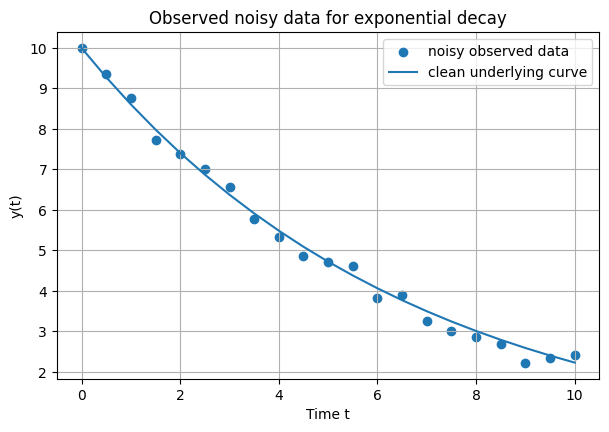

In [3]:
plt.figure(figsize=(7, 4.5))
plt.scatter(t_obs, y_obs, label="noisy observed data")
plt.plot(t_obs, y_clean, label="clean underlying curve")
plt.xlabel("Time t")
plt.ylabel("y(t)")
plt.title("Observed noisy data for exponential decay")
plt.grid(True)
plt.legend()
plt.show()

## 4. Implement Forward Euler

For the ODE

$$
y' = -\lambda y,
$$

the Forward Euler method with step size $h$ gives

$$
y_{n+1} = y_n + h(-\lambda y_n).
$$

We now implement this as a PyTorch function.

The function should:

- take in a value of `lam`,
- take in a step size `h`,
- march from `t=0` to a chosen final time,
- return the full numerical trajectory.

In [6]:
def forward_euler_decay(lam, y0=10.0, h=0.05, t_final=10.0):
    # Solve y' = -lam y, y(0)=y0 by Forward Euler.
    nsteps = int(t_final / h)

    t_values = torch.linspace(0.0, t_final, nsteps + 1)
    y_values = torch.zeros(nsteps + 1)
    y_values[0] = y0

    for n in range(nsteps):
        y_values[n + 1] = y_values[n] + h * (-lam * y_values[n])

    return t_values, y_values

## 5. Test the Forward Euler solver for one value of $\lambda$

Before scanning many parameter values, it is smart to test the solver for just one value.

We choose a trial value of $\lambda$, solve the ODE, and plot the numerical solution.

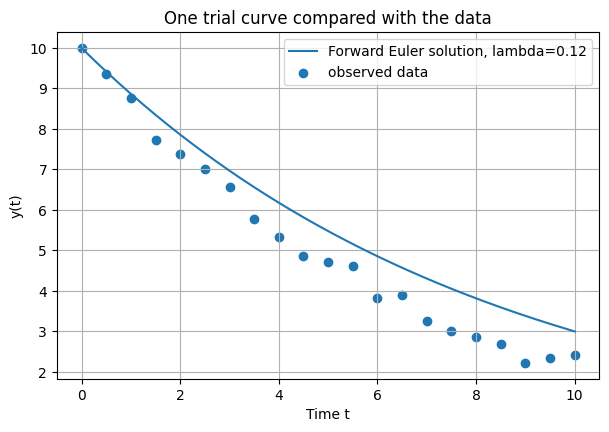

In [7]:
lam_test = 0.12
t_model, y_model = forward_euler_decay(lam_test, y0=y0, h=0.05, t_final=10.0)

plt.figure(figsize=(7, 4.5))
plt.plot(t_model, y_model, label=f"Forward Euler solution, lambda={lam_test:.2f}")
plt.scatter(t_obs, y_obs, label="observed data")
plt.xlabel("Time t")
plt.ylabel("y(t)")
plt.title("One trial curve compared with the data")
plt.grid(True)
plt.legend()
plt.show()

## 6. Define a loss function

To measure how well a chosen $\lambda$ fits the data, we use the **least-squares loss**

$$
L(\lambda) = \frac{1}{N}\sum_{i=1}^N \big(y_\lambda(t_i)-y_i^{obs}\big)^2.
$$

A smaller loss means a better fit.

Since the observation times in `t_obs` line up with the time grid produced by the solver when we use `h=0.05`, we can compare the model and the data directly at those same times.

In [8]:
def loss_for_lambda(lam, t_obs, y_obs, y0=10.0, h=0.05, t_final=10.0):
    # Compute the mean squared error between the Forward Euler solution
    # and the observed data for a given lambda.
    t_model, y_model = forward_euler_decay(lam, y0=y0, h=h, t_final=t_final)

    # Since h=0.05 and t_obs goes 0, 0.5, 1.0, ..., 10.0,
    # the observation times match points on the model grid exactly.
    idx = (t_obs / h).long()
    y_pred = y_model[idx]

    return torch.mean((y_pred - y_obs) ** 2)

## 7. Try several values of $\lambda$

Now we scan over a range of trial values of $\lambda$.

For each one, we:

1. solve the ODE numerically,
2. compare the prediction to the observed data,
3. compute the loss.

This is a simple but very clear way to understand parameter estimation.

In [15]:
lambda_values = torch.linspace(0.05, 0.30, 80)
loss_values = torch.zeros_like(lambda_values)

for i, lam in enumerate(lambda_values):
    loss_values[i] = loss_for_lambda(lam.item(), t_obs, y_obs, y0=y0, h=0.05, t_final=10.0)

print("First few lambda values:")
print(lambda_values[:5])

print("\nFirst few loss values:")
print(loss_values[:5])

First few lambda values:
tensor([0.0500, 0.0532, 0.0563, 0.0595, 0.0627])

First few loss values:
tensor([8.7749, 8.0480, 7.3678, 6.7318, 6.1377])


## 8. Plot several model curves for different values of $\lambda$

Before plotting the loss, it is useful to see what different parameter values do to the curve.

Smaller $\lambda$ gives slower decay.  
Larger $\lambda$ gives faster decay.

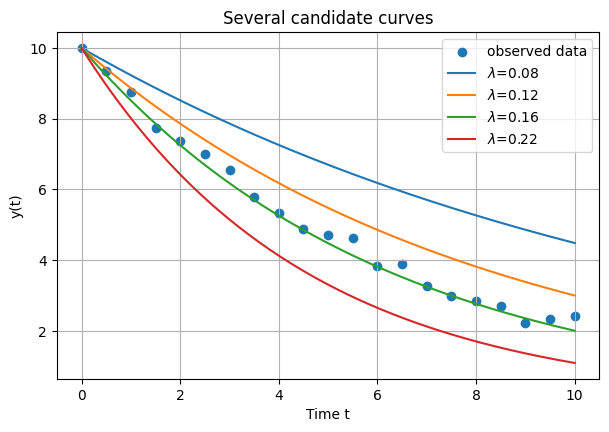

In [16]:
trial_lambdas = [0.08, 0.12, 0.16, 0.22]

plt.figure(figsize=(7, 4.5))
plt.scatter(t_obs, y_obs, label="observed data")

for lam in trial_lambdas:
    t_model, y_model = forward_euler_decay(lam, y0=y0, h=0.05, t_final=10.0)
    plt.plot(t_model, y_model, label=rf"$\lambda$={lam:.2f}")

plt.xlabel("Time t")
plt.ylabel("y(t)")
plt.title("Several candidate curves")
plt.grid(True)
plt.legend()
plt.show()

## 9. Plot the loss curve

We now plot the loss as a function of $\lambda$.

This curve tells us which parameter values fit the data well and which do not.

The best-fit value is the one where the loss is smallest.

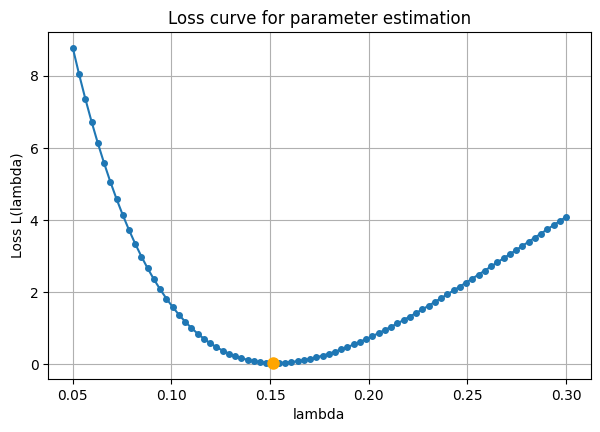

Best lambda from the scan: 0.1513
Smallest loss value: 0.029878


In [17]:
best_index = torch.argmin(loss_values)
lambda_best = lambda_values[best_index].item()
loss_best = loss_values[best_index].item()

plt.figure(figsize=(7, 4.5))
plt.plot(lambda_values, loss_values, marker="o", markersize=4)
plt.plot([lambda_best], [loss_best], marker="o", markersize=8, color="orange")
plt.xlabel("lambda")
plt.ylabel("Loss L(lambda)")
plt.title("Loss curve for parameter estimation")
plt.grid(True)
plt.show()

print(f"Best lambda from the scan: {lambda_best:.4f}")
print(f"Smallest loss value: {loss_best:.6f}")

## 10. Solve the ODE again using the best-fit $\lambda$

Now that we have found the parameter value with the smallest loss, we use it to produce the final fitted curve.

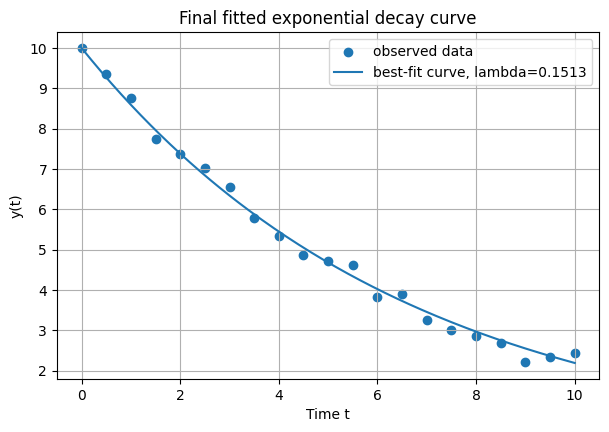

In [18]:
t_fit, y_fit = forward_euler_decay(lambda_best, y0=y0, h=0.05, t_final=10.0)

plt.figure(figsize=(7, 4.5))
plt.scatter(t_obs, y_obs, label="observed data")
plt.plot(t_fit, y_fit, label=f"best-fit curve, lambda={lambda_best:.4f}")
plt.xlabel("Time t")
plt.ylabel("y(t)")
plt.title("Final fitted exponential decay curve")
plt.grid(True)
plt.legend()
plt.show()

## 11. Compare the final fit with the clean curve

This final comparison is useful for teaching.

It shows:

- the noisy data,
- the fitted numerical curve,
- the underlying clean curve.

This helps students see that even when the data are noisy, the fitted parameter can still recover the overall trend well.

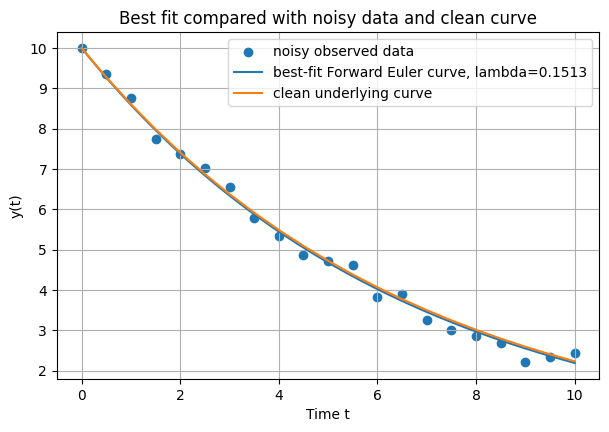

In [19]:
plt.figure(figsize=(7, 4.5))
plt.scatter(t_obs, y_obs, label="noisy observed data")
plt.plot(t_fit, y_fit, label=f"best-fit Forward Euler curve, lambda={lambda_best:.4f}")
plt.plot(t_obs, y_clean, label="clean underlying curve")
plt.xlabel("Time t")
plt.ylabel("y(t)")
plt.title("Best fit compared with noisy data and clean curve")
plt.grid(True)
plt.legend()
plt.show()

## 12. Summary

In this notebook, we did the following:

- loaded noisy data from a `.pt` file,
- plotted the data,
- implemented the Forward Euler method,
- solved the ODE for many values of $\lambda$,
- defined and computed a least-squares loss,
- plotted the loss curve,
- selected the $\lambda$ with the smallest loss,
- used that value to plot the final fitted curve.

This is the basic workflow of **parameter estimation for ODE models**.

In the next step, instead of scanning many values manually, we can use **optimization methods** to update the parameter automatically.